## 0. Setup and constants

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path

SEED = 42
TRAIN_END, VAL_END = 2019, 2021   # train <=2019, val 2020-2021, test >=2022

def find_data_dir():
    kaggle = Path("/kaggle/input")
    if kaggle.exists():
        for p in kaggle.rglob("results.csv"):
            return p.parent
    local = Path("../data/raw")
    if (local / "results.csv").exists():
        return local
    raise FileNotFoundError("results.csv not found")

DATA_DIR = find_data_dir()
print("Using data from:", DATA_DIR.resolve())

Using data from: /run/media/mogus/82DAAF6ADAAF58E5/Users/Asus/GUC_semesters/Semester 9/Advanced Media Lab II/Project/projectCode/f1-podium-ms1/data/raw


## 1. Load raw data

In [3]:
TABLES = ["circuits","constructor_results","constructor_standings","constructors",
          "driver_standings","drivers","lap_times","pit_stops","qualifying",
          "races","results","seasons","sprint_results","status"]

raw   = {t: pd.read_csv(DATA_DIR/f"{t}.csv", dtype=str, keep_default_na=False) for t in TABLES}
clean = {t: pd.read_csv(DATA_DIR/f"{t}.csv", na_values=[r"\N"], keep_default_na=False) for t in TABLES}

In [6]:
#sanity check to see if tabes were loaded 

for t, df in clean.items():
    print(f"{t:22s} {df.shape}")

circuits               (77, 9)
constructor_results    (12625, 5)
constructor_standings  (13391, 7)
constructors           (212, 5)
driver_standings       (34863, 7)
drivers                (861, 9)
lap_times              (589081, 6)
pit_stops              (11371, 7)
qualifying             (10494, 9)
races                  (1125, 18)
results                (26759, 18)
seasons                (75, 2)
sprint_results         (360, 16)
status                 (139, 2)


## 2. EDA before cleaning

### 2a. Tabel overview

In [7]:
summary = pd.DataFrame({
    t: {"rows": len(df), "cols": df.shape[1],
        "mem_MB": round(df.memory_usage(deep=True).sum() / 1e6, 2)}
    for t, df in clean.items()
}).T
display(summary)
display(clean["results"].dtypes)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,rows,cols,mem_MB
circuits,77.0,9.0,0.01
constructor_results,12625.0,5.0,0.51
constructor_standings,13391.0,7.0,0.77
constructors,212.0,5.0,0.02
driver_standings,34863.0,7.0,2.01
drivers,861.0,9.0,0.13
lap_times,589081.0,6.0,32.99
pit_stops,11371.0,7.0,0.80
qualifying,10494.0,9.0,0.92
races,1125.0,18.0,0.26


resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number             float64
grid                 int64
position           float64
positionText           str
positionOrder        int64
points             float64
laps                 int64
time                   str
milliseconds       float64
fastestLap         float64
rank               float64
fastestLapTime         str
fastestLapSpeed    float64
statusId             int64
dtype: object

### 2b. Sentinel audit

,table,column,n_sentinel,pct_sentinel,n_empty_str
13,constructor_results,status,12608,99.865347,0
81,races,sprint_time,1110,98.666667,0
80,races,sprint_date,1107,98.400000,0
77,races,fp3_time,1072,95.288889,0
73,races,fp1_time,1057,93.955556,0
75,races,fp2_time,1057,93.955556,0
79,races,quali_time,1057,93.955556,0
76,races,fp3_date,1053,93.600000,0
35,drivers,number,802,93.147503,0
72,races,fp1_date,1035,92.000000,0


Columns with empty-string placeholders: 2


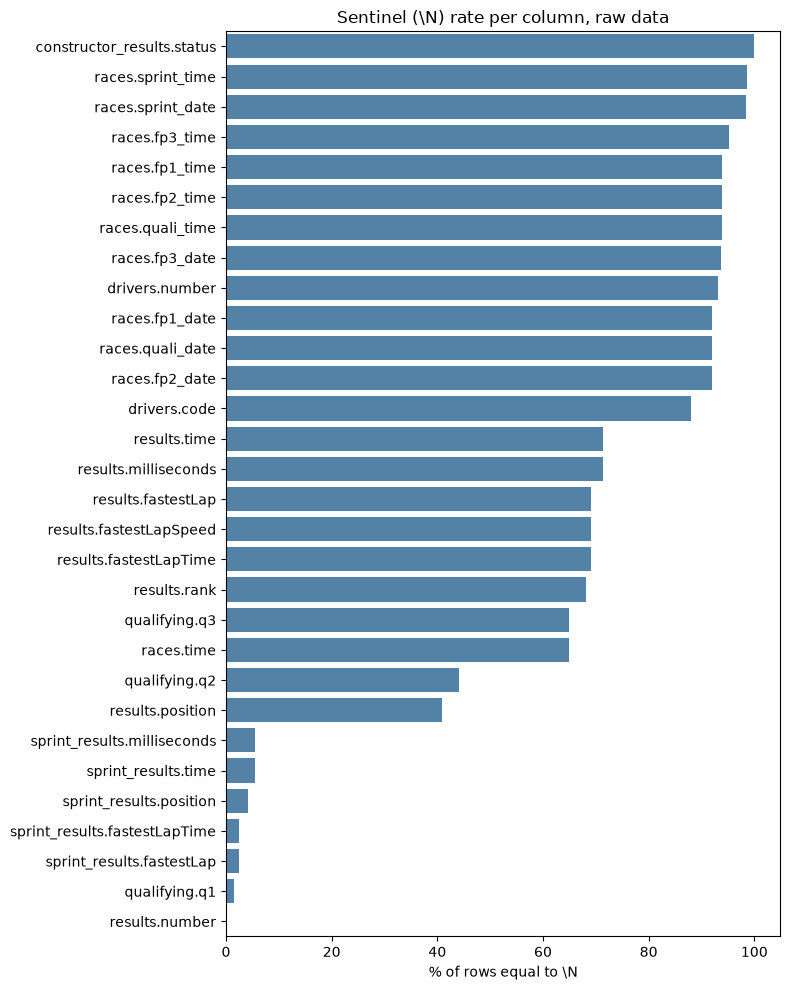

In [8]:
rows = []
for t, df in raw.items():
    for c in df.columns:
        n_sent  = int((df[c] == r"\N").sum())
        n_empty = int((df[c].str.strip() == "").sum())
        rows.append({"table": t, "column": c, "n_sentinel": n_sent,
                     "pct_sentinel": 100 * n_sent / len(df), "n_empty_str": n_empty})
sentinel = pd.DataFrame(rows)

sent_nz = sentinel[sentinel.n_sentinel > 0].sort_values("pct_sentinel", ascending=False)
display(sent_nz)
print("Columns with empty-string placeholders:", int((sentinel.n_empty_str > 0).sum()))

plot_df = sent_nz.assign(label=sent_nz.table + "." + sent_nz.column)
fig, ax = plt.subplots(figsize=(8, 0.3 * len(plot_df) + 1))
sns.barplot(data=plot_df, y="label", x="pct_sentinel", ax=ax, color="steelblue")
ax.set_xlabel("% of rows equal to \\N")
ax.set_ylabel("")
ax.set_title("Sentinel (\\N) rate per column, raw data")
plt.tight_layout()
plt.show()

### 2c. DUplicate (raceID, driverID) pairs

rows involved: 176 | duplicated pairs: 85


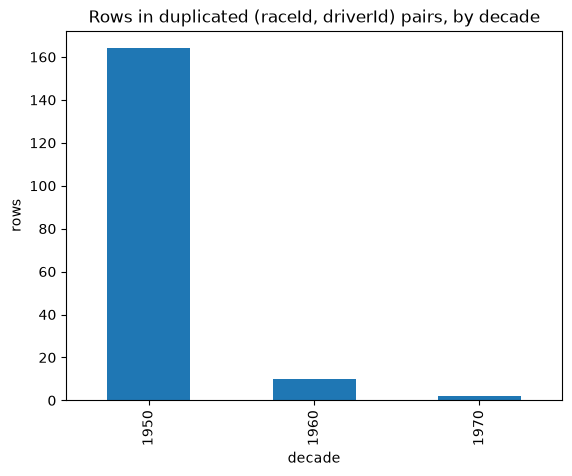

,raceId,driverId,constructorId,grid,positionOrder,points,statusId,year
13188,540,229,54,0,26,0.0,81,1978
13191,540,229,57,0,29,0.0,97,1978
17362,717,373,172,1,7,0.0,60,1964
24298,717,373,172,1,12,0.0,98,1964
17740,733,465,172,0,22,0.0,54,1962
17743,733,465,97,0,25,0.0,54,1962
17961,742,475,102,20,19,0.0,2,1961
17963,742,475,172,5,21,0.0,23,1961
18062,745,418,172,11,17,0.0,6,1961
24297,745,418,172,15,11,0.0,18,1961


In [9]:
res = clean["results"].merge(clean["races"][["raceId", "year"]], on="raceId", how="left")

dups = res[res.duplicated(["raceId", "driverId"], keep=False)]
print("rows involved:", len(dups),
      "| duplicated pairs:", dups.groupby(["raceId", "driverId"]).ngroups)

dups.assign(decade=(dups.year // 10) * 10).groupby("decade").size().plot(
    kind="bar", title="Rows in duplicated (raceId, driverId) pairs, by decade")
plt.ylabel("rows"); plt.show()

dups.sort_values(["raceId", "driverId"]).head(12)[
    ["raceId", "driverId", "constructorId", "grid", "positionOrder", "points", "statusId", "year"]]

### 2d. Qualifying coverage by season

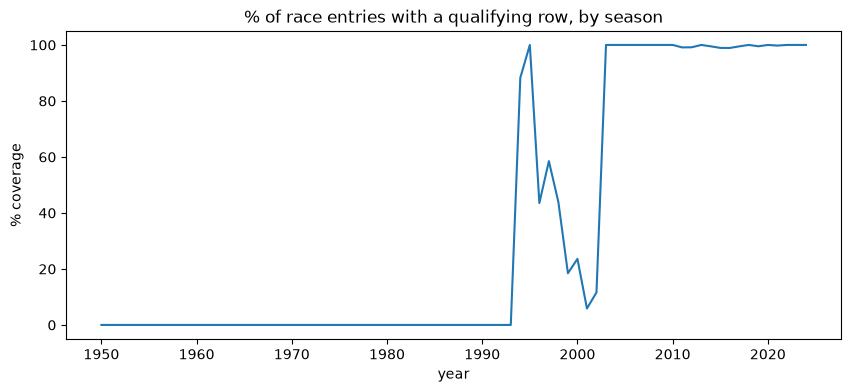

First season with any qualifying data: 1994


In [10]:
base = res[["raceId", "driverId", "year"]].drop_duplicates()
q = clean["qualifying"][["raceId", "driverId"]].drop_duplicates().assign(has_q=1)
cov = base.merge(q, on=["raceId", "driverId"], how="left").fillna({"has_q": 0})
cov_year = cov.groupby("year")["has_q"].mean() * 100

cov_year.plot(figsize=(10, 4), title="% of race entries with a qualifying row, by season")
plt.ylabel("% coverage"); plt.show()
print("First season with any qualifying data:", cov_year[cov_year > 0].index.min())

### 2e. Base rate, field size and grid = 0

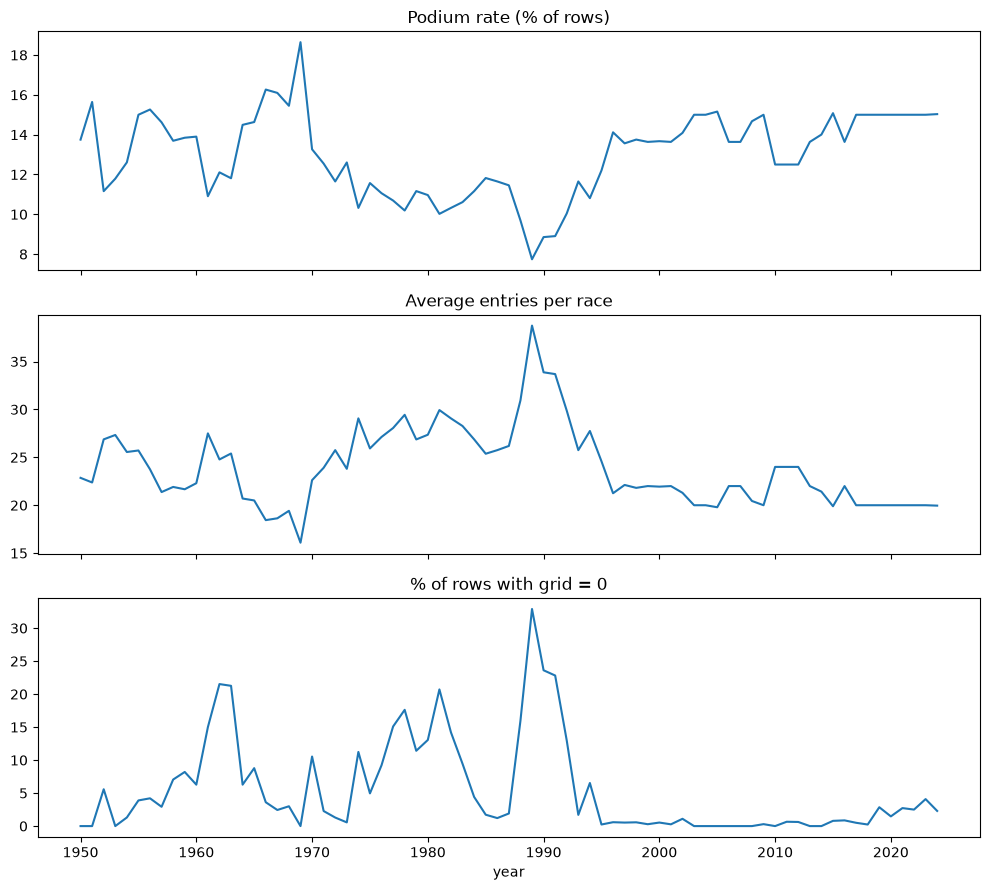

In [11]:
res["podium"] = (res.positionOrder <= 3).astype(int)

podium_rate = res.groupby("year")["podium"].mean() * 100
field_size  = res.groupby(["year", "raceId"]).size().groupby("year").mean()
grid_zero   = (res.grid == 0).groupby(res.year).mean() * 100

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
podium_rate.plot(ax=axes[0], title="Podium rate (% of rows)")
field_size.plot(ax=axes[1], title="Average entries per race")
grid_zero.plot(ax=axes[2], title="% of rows with grid = 0")
plt.tight_layout(); plt.show()

## 3. Cleaning

## 4. Integrity checks (PK/FK)

## 5. EDA after cleaning

## 6. Data analysis: impact of cleaning

## 7. Build and export the modeling base table

## 8. Data contract and decisions